In [5]:
import json
import os
import re
import time
from pathlib import Path
from typing import Dict

from dotenv import load_dotenv

from langchain_core.prompts import ChatPromptTemplate
from langchain_google_genai import ChatGoogleGenerativeAI

from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import Select


# ============================================================
# Paths and logging
# ============================================================

# IMPORTANT:
# Because this code is being run inside Jupyter Notebook,
# __file__ is not available.
#
# Therefore we use the current working directory.

BASE_DIR = Path.cwd()

LOG_DIR = BASE_DIR / "logs"
LOG_DIR.mkdir(exist_ok=True)

LOG_FILE = LOG_DIR / "web_agent_log.txt"


# ============================================================
# Logging function
# ============================================================

def log_step(message: str) -> None:
    """
    Write a timestamped message to the log file
    and also print it in the terminal/notebook.
    """

    stamp = time.strftime("%Y-%m-%d %H:%M:%S")

    line = f"[{stamp}] {message}"

    with open(
        LOG_FILE,
        "a",
        encoding="utf-8",
    ) as file:
        file.write(line + "\n")

    print(line)


# ============================================================
# Convert LangChain response to text
# ============================================================

def text_from_response(message) -> str:
    """
    Convert the Gemini/LangChain response into plain text.

    Depending on the installed versions of LangChain and
    langchain-google-genai, response.content can be:

    1. A normal string
    2. A list containing dictionaries
    3. A list containing content objects
    """

    content = getattr(
        message,
        "content",
        "",
    )

    # --------------------------------------------------------
    # Case 1: content is already a string
    # --------------------------------------------------------

    if isinstance(content, str):
        return content

    # --------------------------------------------------------
    # Case 2: content is a list
    # --------------------------------------------------------

    if isinstance(content, list):

        parts = []

        for item in content:

            # -----------------------------------------------
            # Dictionary content
            # -----------------------------------------------

            if isinstance(item, dict):

                if "text" in item:
                    parts.append(
                        str(item["text"])
                    )

            # -----------------------------------------------
            # Object with .text
            # -----------------------------------------------

            elif hasattr(item, "text"):

                parts.append(
                    str(item.text)
                )

        if parts:
            return "\n".join(parts)

    # --------------------------------------------------------
    # Fallback
    # --------------------------------------------------------

    return str(content)


# ============================================================
# Extract JSON from model response
# ============================================================

def extract_json(text: str) -> Dict[str, str]:
    """
    Extract a JSON dictionary from the LLM response.

    Handles responses such as:

    {"name": "Anshu", ...}

    or:

    ```json
    {"name": "Anshu", ...}
    ```
    """

    cleaned = text.strip()

    # --------------------------------------------------------
    # Remove ```json
    # --------------------------------------------------------

    cleaned = re.sub(
        r"^```json\s*",
        "",
        cleaned,
        flags=re.IGNORECASE,
    )

    # --------------------------------------------------------
    # Remove closing ```
    # --------------------------------------------------------

    cleaned = re.sub(
        r"\s*```$",
        "",
        cleaned,
    )

    cleaned = cleaned.strip()

    # --------------------------------------------------------
    # First attempt:
    # Parse entire response
    # --------------------------------------------------------

    try:

        parsed = json.loads(
            cleaned
        )

        if isinstance(parsed, dict):
            return parsed

    except json.JSONDecodeError:
        pass

    # --------------------------------------------------------
    # Second attempt:
    # Find JSON object inside response
    # --------------------------------------------------------

    match = re.search(
        r"\{.*\}",
        cleaned,
        re.DOTALL,
    )

    if match:

        try:

            parsed = json.loads(
                match.group(0)
            )

            if isinstance(parsed, dict):
                return parsed

        except json.JSONDecodeError:
            pass

    # --------------------------------------------------------
    # Nothing worked
    # --------------------------------------------------------

    raise ValueError(
        "Could not extract valid JSON from model response.\n\n"
        f"Model response:\n{cleaned}"
    )


# ============================================================
# Build structured task using Gemini
# ============================================================

def build_structured_task(
    llm: ChatGoogleGenerativeAI,
    user_request: str,
    feedback: str,
) -> Dict[str, str]:

    # --------------------------------------------------------
    # Create prompt
    #
    # IMPORTANT:
    # {{ and }} are used because ChatPromptTemplate treats
    # {something} as a template variable.
    # --------------------------------------------------------

    prompt = ChatPromptTemplate.from_messages(
        [
            (
                "system",
                """
You are a task-structuring assistant.

Convert the user's natural-language request into JSON.

The JSON must contain exactly these four keys:

{{
    "name": "",
    "task": "",
    "priority": "",
    "notes": ""
}}

Rules:

1. "name" must contain the person's name.
2. "task" must contain the task to be completed.
3. "priority" must be exactly:
   low
   medium
   high
4. "notes" must contain additional useful information.
5. If information is not provided, use an empty string.
6. Return ONLY valid JSON.
7. Do not use Markdown.
8. Do not use ```json.
""",
            ),
            (
                "human",
                """
Main request:
{request}

Extra feedback:
{feedback}
""",
            ),
        ]
    )

    # --------------------------------------------------------
    # Create LangChain chain
    # --------------------------------------------------------

    chain = prompt | llm

    # --------------------------------------------------------
    # Send request to Gemini
    # --------------------------------------------------------

    response = chain.invoke(
        {
            "request": user_request,
            "feedback": feedback,
        }
    )

    # --------------------------------------------------------
    # Convert response to plain text
    # --------------------------------------------------------

    response_text = text_from_response(
        response
    )

    # --------------------------------------------------------
    # Print raw response for debugging
    # --------------------------------------------------------

    print("\nRaw LLM response:")
    print(response_text)

    # --------------------------------------------------------
    # Log response
    # --------------------------------------------------------

    log_step(
        f"LLM structured response: {response_text}"
    )

    # --------------------------------------------------------
    # Extract JSON
    # --------------------------------------------------------

    task_data = extract_json(
        response_text
    )

    # --------------------------------------------------------
    # Required fields
    # --------------------------------------------------------

    required_keys = [
        "name",
        "task",
        "priority",
        "notes",
    ]

    # --------------------------------------------------------
    # Add missing fields
    # --------------------------------------------------------

    for key in required_keys:

        if key not in task_data:
            task_data[key] = ""

    # --------------------------------------------------------
    # Validate priority
    # --------------------------------------------------------

    priority = str(
        task_data["priority"]
    ).lower().strip()

    if priority not in {
        "low",
        "medium",
        "high",
    }:

        priority = "medium"

    task_data["priority"] = priority

    # --------------------------------------------------------
    # Return clean dictionary
    # --------------------------------------------------------

    return {
        "name": str(
            task_data["name"]
        ),
        "task": str(
            task_data["task"]
        ),
        "priority": priority,
        "notes": str(
            task_data["notes"]
        ),
    }


# ============================================================
# Selenium browser automation
# ============================================================

def automate_task_page(
    task_data: Dict[str, str],
) -> None:

    log_step(
        "Starting browser automation..."
    )

    # --------------------------------------------------------
    # Start Chrome
    # --------------------------------------------------------

    driver = webdriver.Chrome()

    try:

        # ----------------------------------------------------
        # Locate HTML file
        # ----------------------------------------------------

        html_file = (
            BASE_DIR / "04_web_agent.html"
        )

        # ----------------------------------------------------
        # Check HTML file
        # ----------------------------------------------------

        if not html_file.exists():

            raise FileNotFoundError(
                "\nHTML file was not found.\n"
                f"Expected location:\n{html_file}\n\n"
                "Make sure 04_web_agent.html is in the "
                "same directory as your notebook."
            )

        # ----------------------------------------------------
        # Open local HTML file
        # ----------------------------------------------------

        driver.get(
            html_file.as_uri()
        )

        log_step(
            f"Opened webpage: {html_file}"
        )

        # ----------------------------------------------------
        # Wait for webpage
        # ----------------------------------------------------

        time.sleep(1)

        # ====================================================
        # NAME
        # ====================================================

        name_input = driver.find_element(
            By.ID,
            "name",
        )

        name_input.clear()

        name_input.send_keys(
            task_data["name"]
        )

        log_step(
            f"Entered name: {task_data['name']}"
        )

        # ====================================================
        # TASK
        # ====================================================

        task_input = driver.find_element(
            By.ID,
            "task",
        )

        task_input.clear()

        task_input.send_keys(
            task_data["task"]
        )

        log_step(
            f"Entered task: {task_data['task']}"
        )

        # ====================================================
        # PRIORITY
        # ====================================================

        priority_select = driver.find_element(
            By.ID,
            "priority",
        )

        # Using Selenium Select is more reliable for
        # HTML <select> elements.

        select = Select(
            priority_select
        )

        select.select_by_value(
            task_data["priority"]
        )

        log_step(
            f"Selected priority: {task_data['priority']}"
        )

        # ====================================================
        # NOTES
        # ====================================================

        notes_input = driver.find_element(
            By.ID,
            "notes",
        )

        notes_input.clear()

        notes_input.send_keys(
            task_data["notes"]
        )

        log_step(
            "Entered notes."
        )

        # ====================================================
        # SUBMIT
        # ====================================================

        submit_button = driver.find_element(
            By.ID,
            "submitBtn",
        )

        submit_button.click()

        log_step(
            "Clicked Create Task button."
        )

        # ----------------------------------------------------
        # Wait for JavaScript result
        # ----------------------------------------------------

        time.sleep(1)

        # ====================================================
        # READ RESULT
        # ====================================================

        result = driver.find_element(
            By.ID,
            "result",
        )

        result_text = result.text

        log_step(
            f"Webpage result:\n{result_text}"
        )

        print(
            "\n========================================"
        )

        print(
            "WEBPAGE RESULT"
        )

        print(
            "========================================"
        )

        print(
            result_text
        )

        print(
            "========================================\n"
        )

        # ----------------------------------------------------
        # Keep browser open for 3 seconds
        # ----------------------------------------------------

        time.sleep(3)

    finally:

        # ----------------------------------------------------
        # Always close Chrome
        # ----------------------------------------------------

        # driver.quit()

        log_step(
            "Browser automation completed. Browser left open."
        )


# ============================================================
# Main function
# ============================================================

def main() -> None:

    # --------------------------------------------------------
    # Load .env
    # --------------------------------------------------------

    load_dotenv()

    # --------------------------------------------------------
    # Check API key
    # --------------------------------------------------------

    api_key = os.getenv(
        "GOOGLE_API_KEY"
    )

    if not api_key:

        raise RuntimeError(
            "GOOGLE_API_KEY is missing in your .env file."
        )

    # --------------------------------------------------------
    # Create Gemini LLM
    # --------------------------------------------------------

    llm = ChatGoogleGenerativeAI(
        model="gemini-3.6-flash",
        temperature=0,
    )

    # --------------------------------------------------------
    # User's natural-language request
    # --------------------------------------------------------

    user_request = (
        "Create a task for Anshu. "
        "He needs to finish the Python Agentic AI project "
        "as soon as possible. "
        "This is an important task."
    )

    # --------------------------------------------------------
    # Additional feedback
    # --------------------------------------------------------

    feedback = (
        "Set the priority appropriately. "
        "Mention that the project should be completed soon."
    )

    # --------------------------------------------------------
    # Display user request
    # --------------------------------------------------------

    print(
        "\nUser request:"
    )

    print(
        user_request
    )

    print(
        "\nBuilding structured task...\n"
    )

    # --------------------------------------------------------
    # Ask Gemini to structure request
    # --------------------------------------------------------

    task_data = build_structured_task(
        llm,
        user_request,
        feedback,
    )

    # --------------------------------------------------------
    # Display structured task
    # --------------------------------------------------------

    print(
        "\nStructured task:"
    )

    print(
        json.dumps(
            task_data,
            indent=4,
        )
    )

    # --------------------------------------------------------
    # Log structured task
    # --------------------------------------------------------

    log_step(
        "Structured task: "
        + json.dumps(task_data)
    )

    # --------------------------------------------------------
    # Start Selenium automation
    # --------------------------------------------------------

    automate_task_page(
        task_data
    )


# ============================================================
# Entry point
# ============================================================

if __name__ == "__main__":
    main()


User request:
Create a task for Anshu. He needs to finish the Python Agentic AI project as soon as possible. This is an important task.

Building structured task...



c:\Users\sanjo\AppData\Local\Programs\Python\Python310\lib\site-packages\langchain_google_genai\chat_models.py:3120: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(



Raw LLM response:
{
    "name": "Anshu",
    "task": "Finish the Python Agentic AI project",
    "priority": "high",
    "notes": "The project should be completed as soon as possible."
}
[2026-08-10 18:28:09] LLM structured response: {
    "name": "Anshu",
    "task": "Finish the Python Agentic AI project",
    "priority": "high",
    "notes": "The project should be completed as soon as possible."
}

Structured task:
{
    "name": "Anshu",
    "task": "Finish the Python Agentic AI project",
    "priority": "high",
    "notes": "The project should be completed as soon as possible."
}
[2026-08-10 18:28:09] Structured task: {"name": "Anshu", "task": "Finish the Python Agentic AI project", "priority": "high", "notes": "The project should be completed as soon as possible."}
[2026-08-10 18:28:09] Starting browser automation...
[2026-08-10 18:28:11] Opened webpage: c:\Users\sanjo\OneDrive\Desktop\python_agent_demo_bundle\04_web_agent.html
[2026-08-10 18:28:12] Entered name: Anshu
[2026-08-10

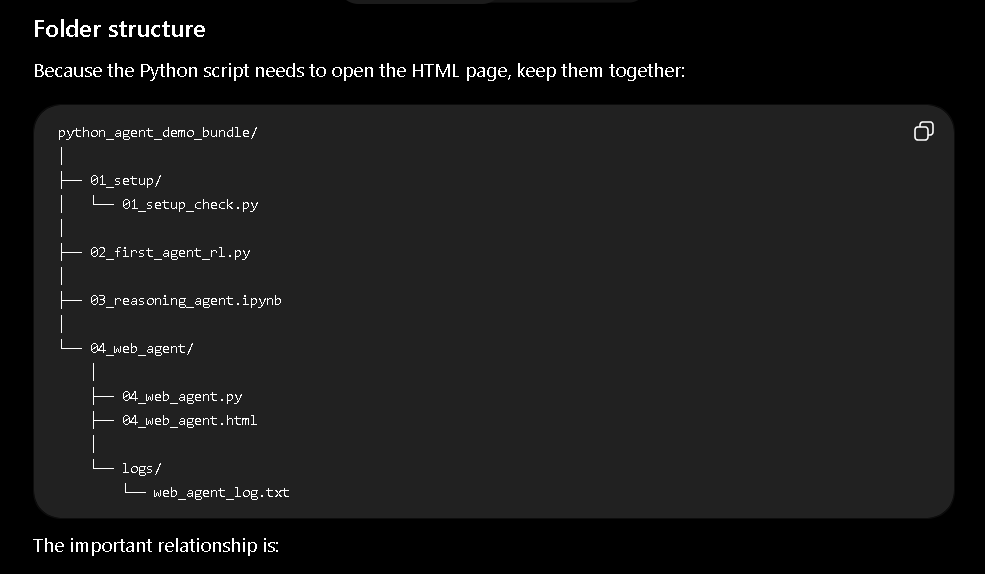
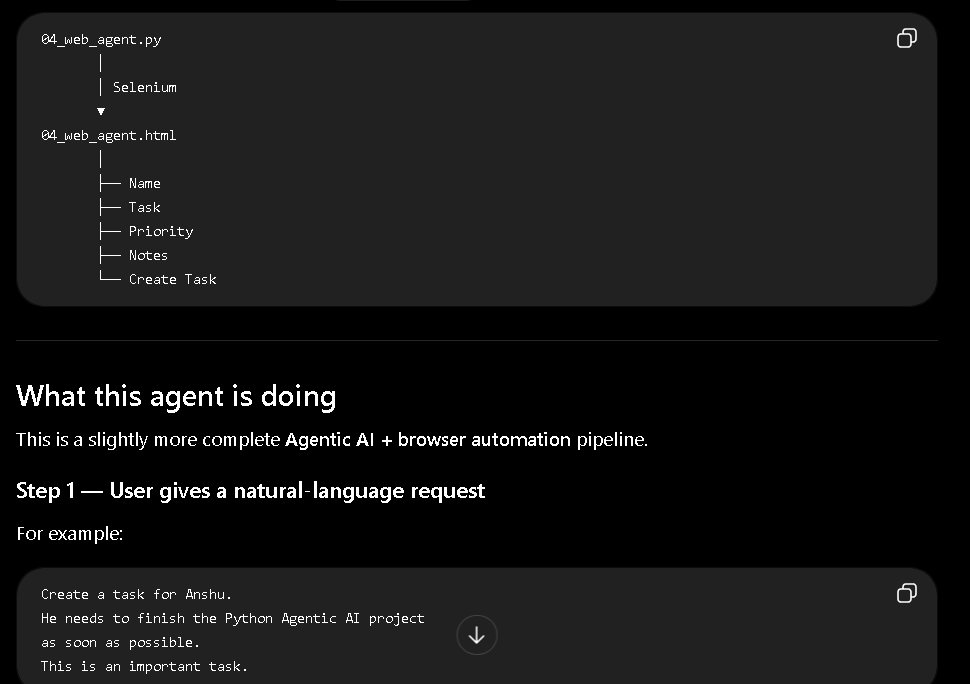
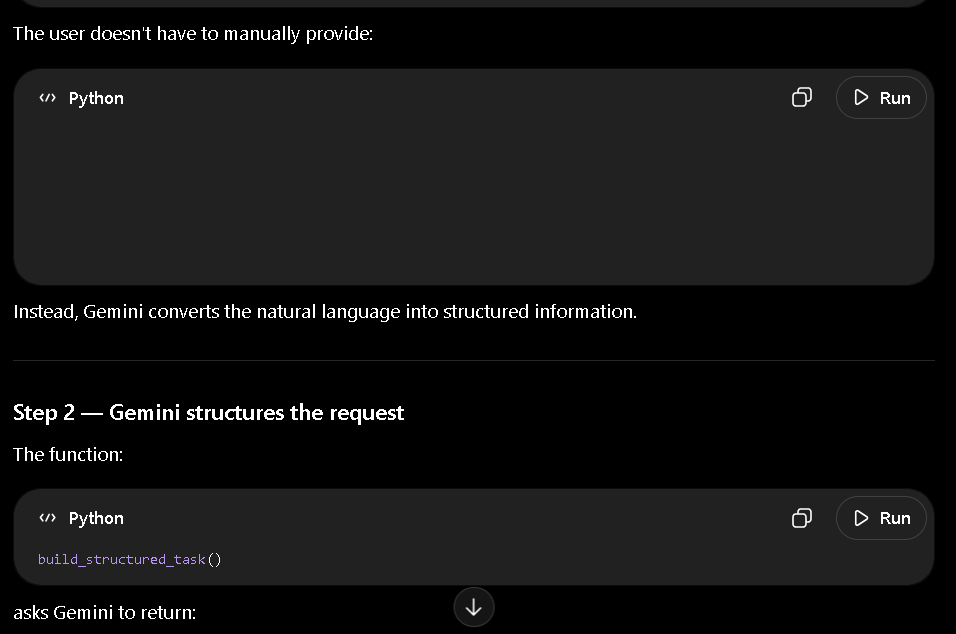
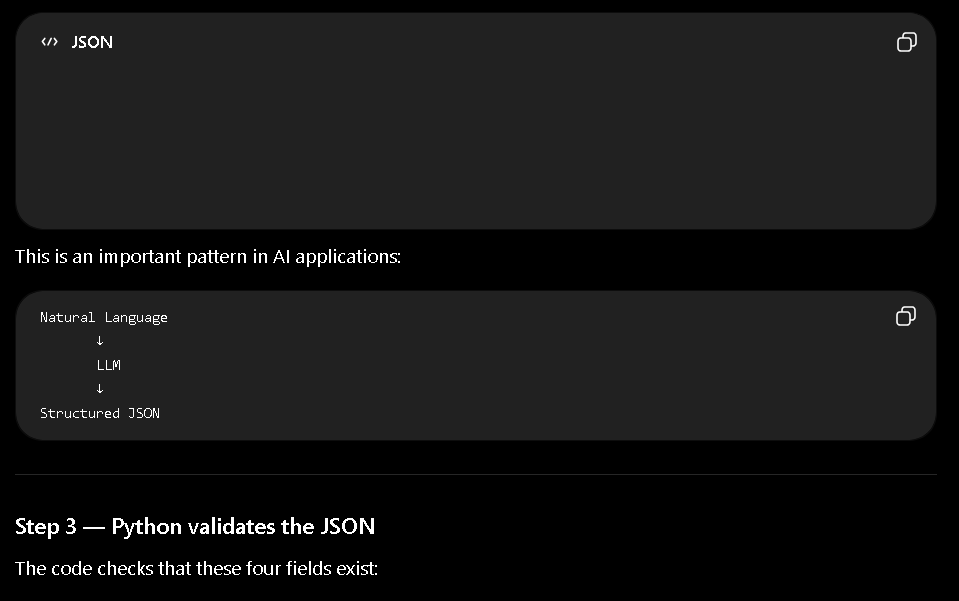
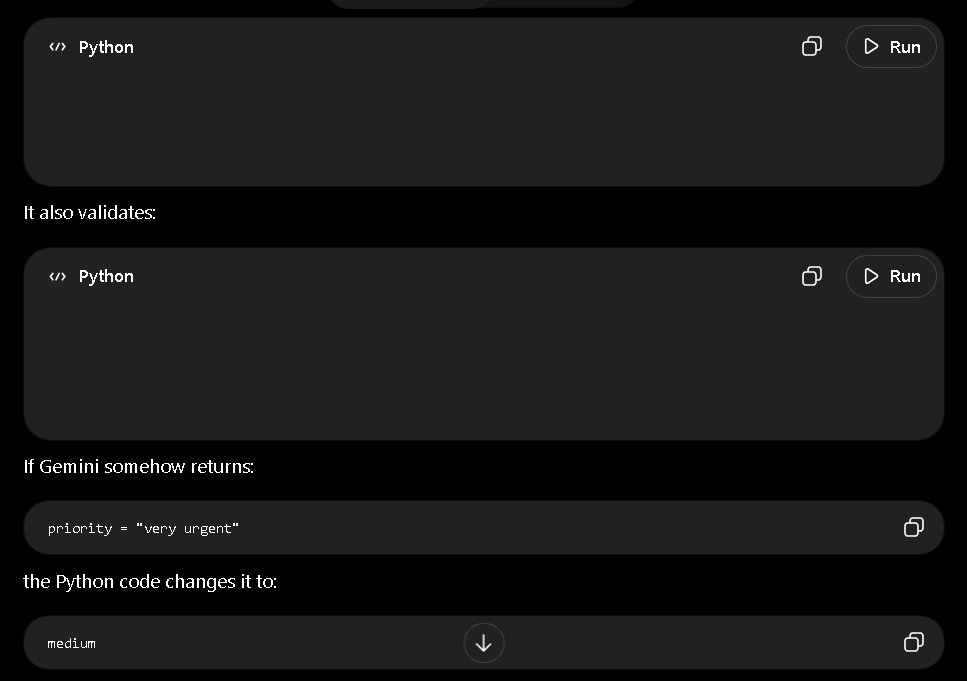
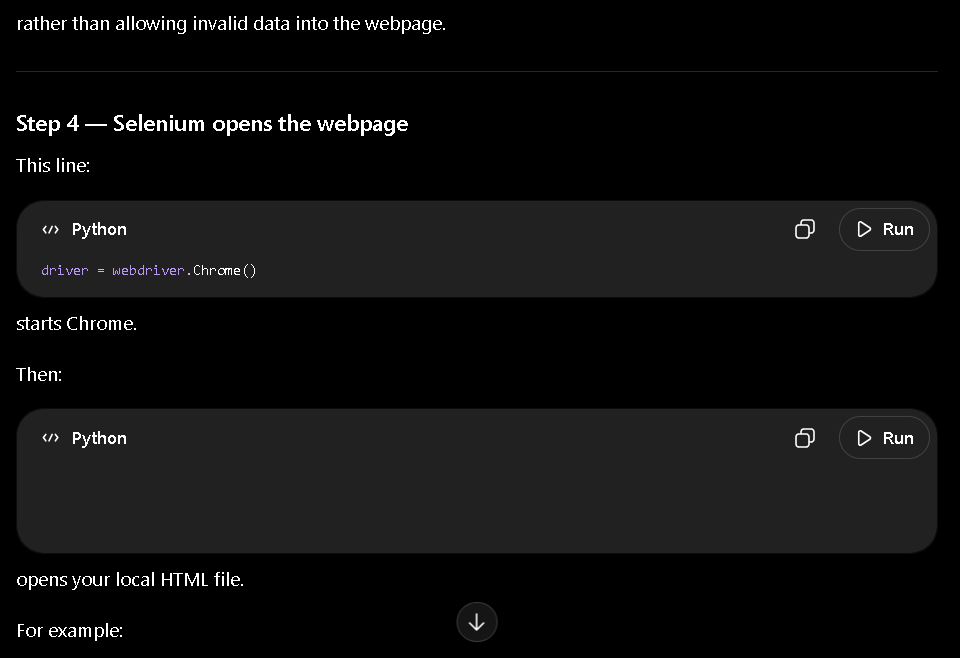
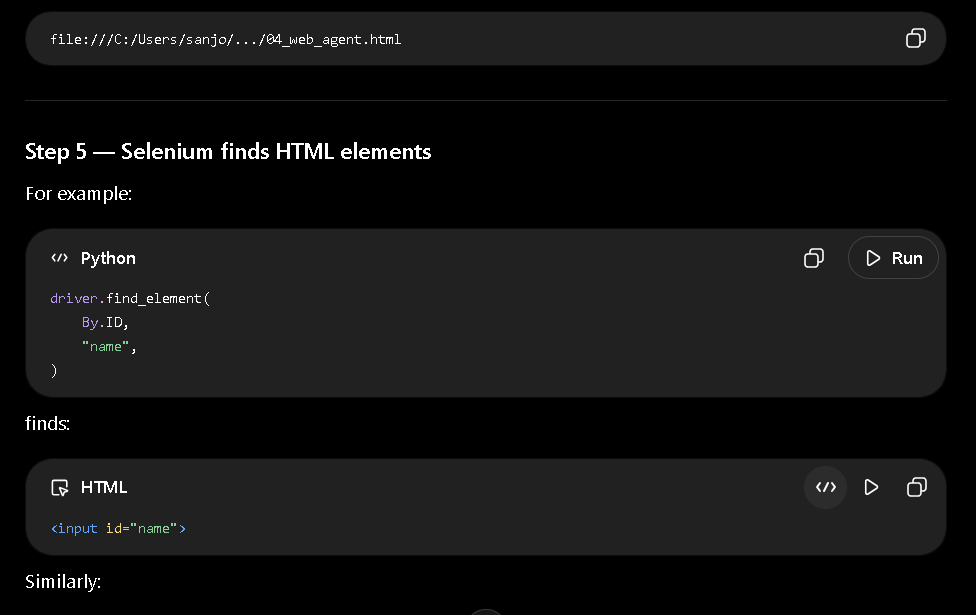
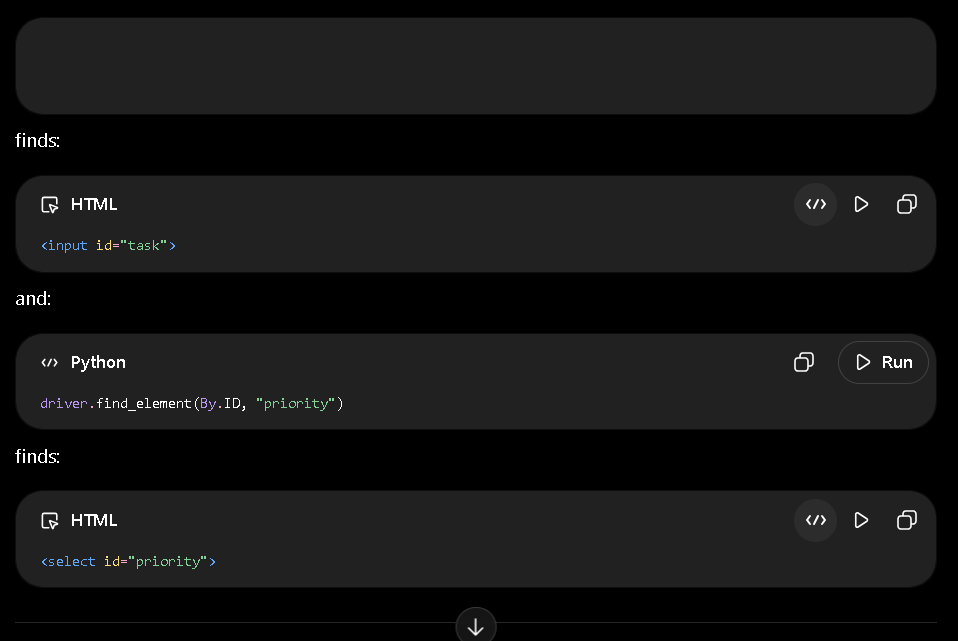
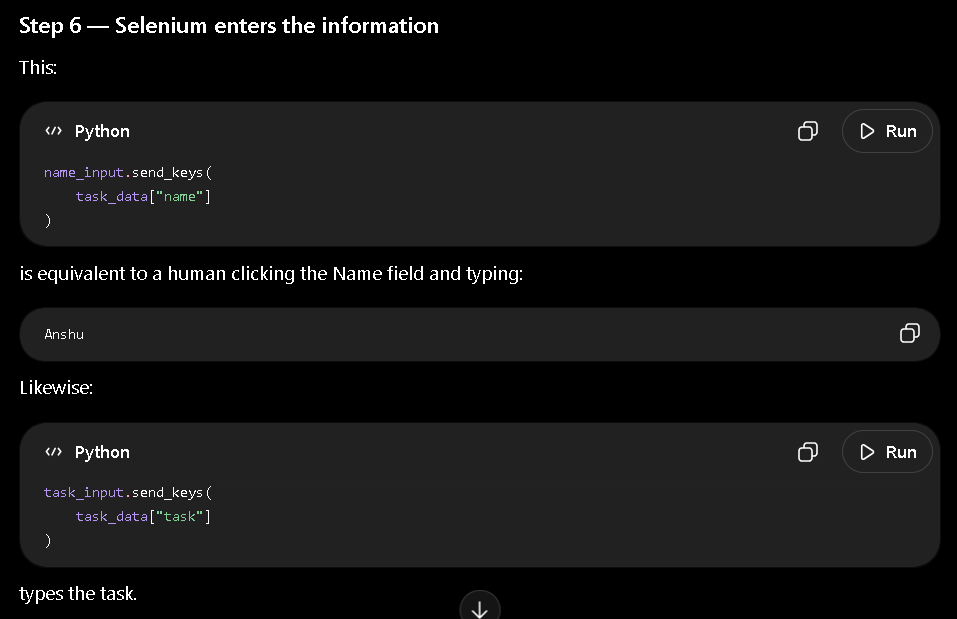
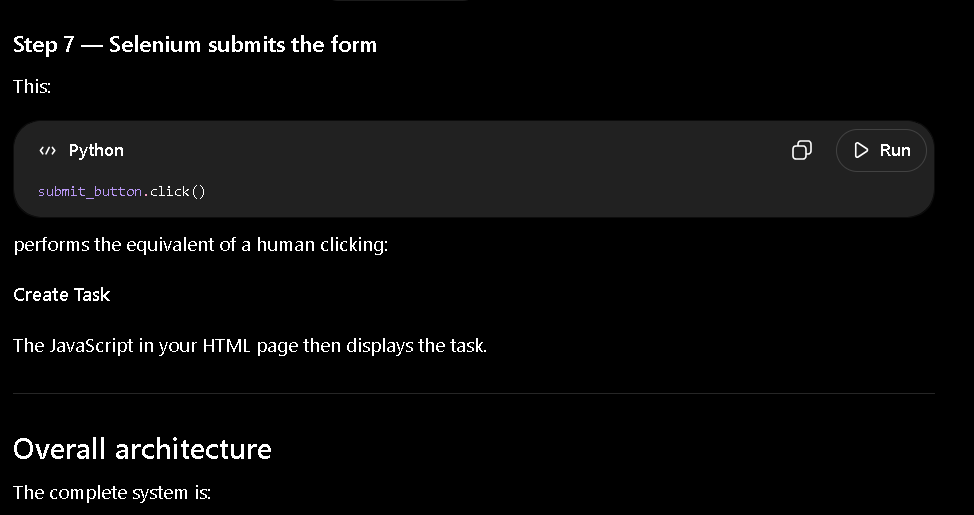
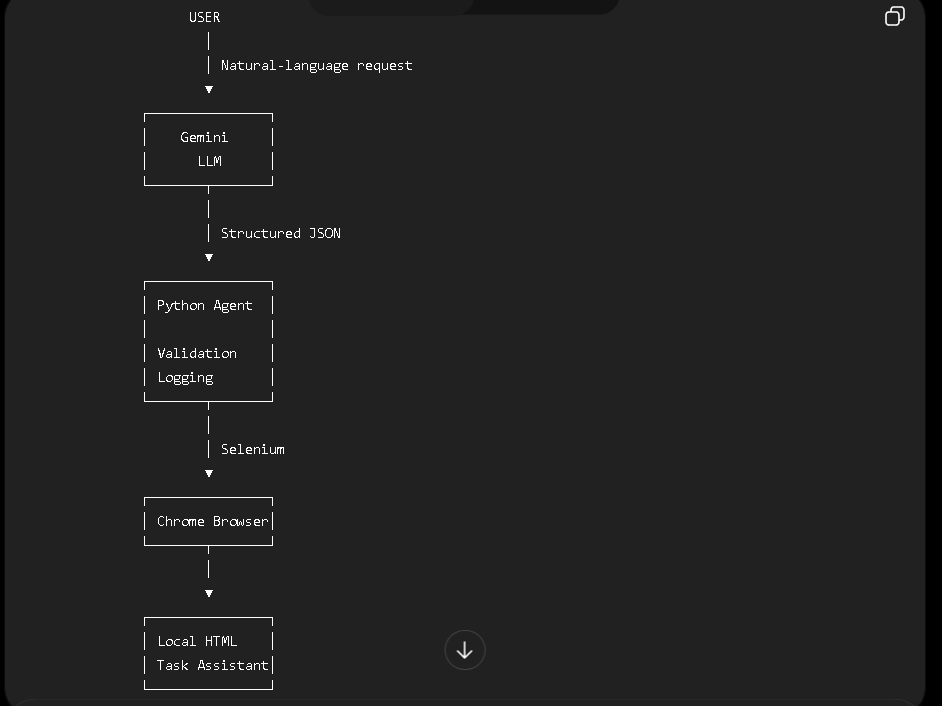
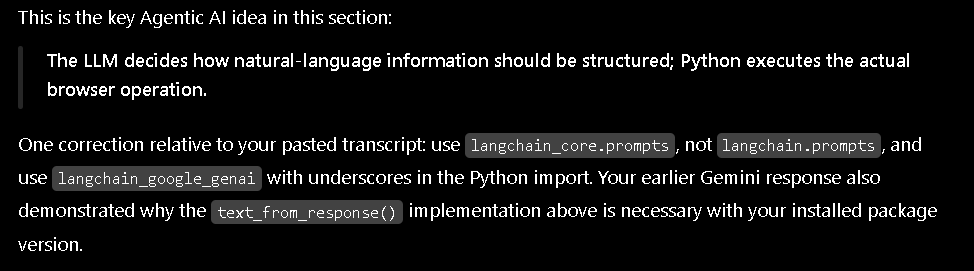